Figure parameters

In [69]:
import numpy as np
import xtrack as xt
import xobjects as xo
import xpart as xp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import constants 
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter
from ipywidgets import interact, IntSlider
import pickle

import numpy as np
import matplotlib.pyplot as plt
from scipy import constants 
from scipy.optimize import curve_fit
import scipy.constants as const
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy import constants 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm  # Importing tqdm for progress bar
import matplotlib.ticker as ticker
import json

# Generalized variables
textwidth_cm = 15  # Text width in cm
aspect_ratio = 0.618     # Aspect ratio (height/width) using the golden ratio

# Font sizes
label_fontsize = 12
legend_fontsize = 12
tick_fontsize = 10
colorbar_label_fontsize = 12
colorbar_tick_fontsize = 10
offset_text_fontsize = 12
tick_fontsize = 10
errorbar_capsize = 5

# Convert text width from cm to inches
textwidth_in = textwidth_cm / 2.54

# Calculate figure size based on text width and aspect ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

save_dir = '/home/pkruyt/cernbox/figures_thesis_pdf/ibs_vs_laser/'

In [70]:
from ion_properties import lead,xenon,calcium

ions=[lead,xenon,calcium]


In [71]:
def freedman_diaconis_bins(data):
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    bins = int((np.max(data) - np.min(data)) / bin_width)
    return max(1, bins)  # Ensure at least 1 bin

def extract_core_pdf_threshold(data, threshold=1000):
    """
    Extracts the core of a distribution by keeping points with estimated PDF
    >= max_pdf / threshold. Works with NumPy or CuPy via np interface.

    Parameters
    ----------
    np : module
        The numerical backend (np or cp).
    data : array
        The 1D data array to extract the core from.
    threshold : float, optional
        PDF threshold factor. Points with PDF less than max_pdf / threshold
        will be considered outliers. Default is 1000.

    Returns
    -------
    core_data : array
        1D array of data values that belong to the core.
    """
    if len(data) < 2:
        return data

    # Freedman–Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    bin_width = 2 * iqr * len(data) ** (-1 / 3)
    data_min = float(np.min(data))
    data_max = float(np.max(data))
    if bin_width == 0 or data_max == data_min:
        return data

    n_bins = int(np.maximum(5, np.ceil((data_max - data_min) / bin_width)))
    bin_edges = np.asarray(np.linspace(data_min, data_max, n_bins + 1))
    bin_width = bin_edges[1] - bin_edges[0]

    # Bin index assignment
    indices = np.floor((data - bin_edges[0]) / bin_width).astype(int)
    indices = np.clip(indices, 0, n_bins - 1)

    # Compute PDF manually
    counts = np.zeros(n_bins, dtype=float)
    for i in range(len(data)):
        counts[indices[i]] += 1
    counts = counts / (np.sum(counts) * bin_width)

    max_pdf = np.max(counts)
    print(max_pdf)
    pdf_at_points = counts[indices]
    mask = pdf_at_points >= max_pdf / threshold
    print(mask)
    return data[mask]


def extract_core_mad_fast(data, scale=3.0):
    """
    Very fast core estimator using median and MAD.
    Keeps values within `scale * MAD` of median.
    """
    med = np.median(data)
    mad = np.median(np.abs(data - med))
    threshold = scale * mad * 1.4826  # Convert MAD to sigma for Gaussian
    return data[np.abs(data - med) < threshold]

def core_width(data):
    core_width_list=[]
    delta=data['delta']
    state=data['state']
    for turn in range(delta.shape[0]):
        data=delta[turn]
        p20, p80 = np.percentile(data, [15, 85])
        core = data[(data >= p20) & (data <= p80)]
        core_width=(p80-p20)/2
        core_width_list.append(core_width)
    return core_width_list

def plot_quiver(emittance, rms_dp_p, time, color, label,num_segments=10):
    # num_segments = 10
    step_size = len(time) // num_segments

    for j in range(num_segments):
        start_idx = j * step_size
        end_idx = min((j + 1) * step_size, len(time) - 1)
        
        start_x = emittance[start_idx]
        end_x = emittance[end_idx]
        
        start_y = rms_dp_p[start_idx]
        end_y = rms_dp_p[end_idx]
        
        arrow = plt.quiver(start_x, start_y, end_x - start_x, end_y - start_y, scale=1,
                            scale_units='xy', angles='xy', color=color, width=0.003)
        
        time_annotation_x = end_x
        time_annotation_y = end_y
        if j == num_segments - 1:
            time_annotation_text = "100.0s"
            time_annotation_y = 0.98 * time_annotation_y
        else:
            time_annotation_text = f"{time[end_idx]:.1f}s"
        #plt.text(time_annotation_x, time_annotation_y, time_annotation_text, color='black', fontsize=10, ha='right', va='bottom')

In [72]:
# context = xo.ContextCpu(omp_num_threads=4)
context = xo.ContextCpu()

with open('sps.json', 'r') as f:
    line = xt.Line.from_dict(json.load(f))  
particle_ref=line.particle_ref
line.build_tracker()

clight=constants.speed_of_light
circumference=line.get_length()

Xcoll not installed


Loading line from dict:   0%|          | 0/38786 [00:00<?, ?it/s]

Done loading line from dict.           
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


Loop over both sig_delta and emittance

In [73]:
# # # Load the data from the saved .npz file
# loaded_data = np.load('../linear_lattice/results/cooling_rates.npz')
# transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
# longitudinal_growth_rate=loaded_data['longitudinal_growth_rate']

# loaded_data = np.load('../linear_lattice/results/optimal_laser_x/{ion_loop.name}.npz')
# transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
# longitudinal_growth_rate=loaded_data['longitudinal_growth_rate']



lead zoom in contour plot

In [74]:
# import numpy as np
# import matplotlib.pyplot as plt
# from tqdm import tqdm

# for i, ion_loop in tqdm(enumerate([lead])):
#     data = np.load(f'IBS_results_bunched/{ion_loop.name}.npz')
#     growth_rates_2d_x = data['growth_rates_2d_x']
#     growth_rates_2d_y = data['growth_rates_2d_y']
#     growth_rates_2d_z = data['growth_rates_2d_z']
#     sig_delta_list = data['sig_delta_list']
#     n_emitt_list = data['n_emitt_list']
#     total_intensity = data['total_intensity']

#     plt.figure(figsize=(12, 8))
#     plt.rcParams.update({'font.size': 25})

#     # Plot the contour plot
#     half_height = len(sig_delta_list) // 100
#     half_width = len(n_emitt_list) // 100
#     contour = plt.contourf(n_emitt_list[half_width:], sig_delta_list[half_height:], growth_rates_2d_x[half_height:, half_width:], cmap='viridis')
    
#     cbar = plt.colorbar(contour)
#     cbar.set_label('growth_rates_2d_x', fontsize=20)

#     plt.xlabel('geometrical emittance $\epsilon_x [\mu m]$', fontsize=20)
#     plt.ylabel('RMS dp/p', fontsize=20)
#     plt.title(f'Cooler growth rates: ({ion_loop.name}): {transverse_growth_rate_list[i]:.2f}')
#     plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
#     plt.tight_layout()

#     plt.show()


calcium growth rates

0it [00:00, ?it/s]

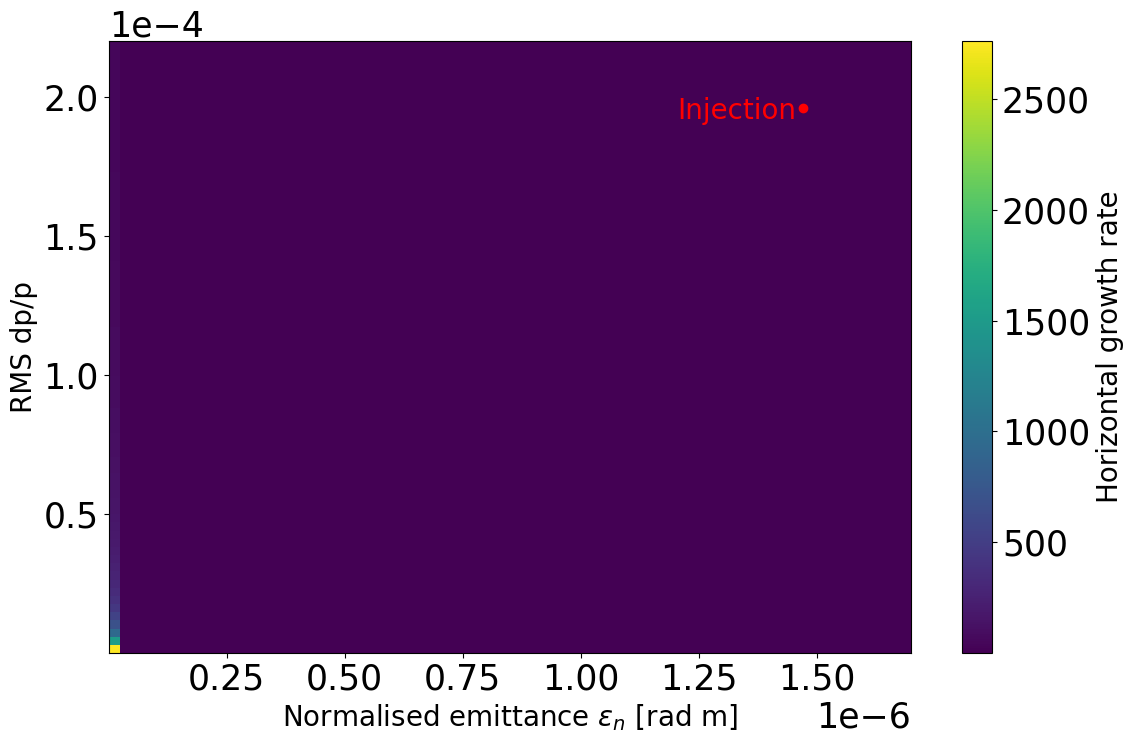

1it [00:00,  5.15it/s]


In [75]:
injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
injection_dp_p = 2e-4

for i,ion_loop in tqdm(enumerate([calcium])):

    data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
    # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
    # max_growth_rate=growth_rates_2d_x
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})

    # Plot the heatmap
    plt.imshow(growth_rates_2d_x, extent=[n_emitt_list.min(), n_emitt_list.max(), sig_delta_list[0], sig_delta_list[-1]],
               aspect='auto', origin='lower', cmap='viridis',norm=None)
       
    cbar = plt.colorbar()
    cbar.set_label('Horizontal growth rate', fontsize=20)

    # Add injection point
    plt.scatter(0.98*injection_nemitt, 0.98*injection_dp_p, color='red', label='Injection Point')
    plt.text(0.97*injection_nemitt, 0.96*injection_dp_p, 'Injection', color='red', fontsize=20, ha='right')

    #contour = plt.contour(geo_epsx_list, sig_delta_list, growth_rates_2d_x, levels=[threshold], colors='red', linewidths=2)
    plt.xlabel('Normalised emittance $\\epsilon_n$ [rad m]', fontsize=20)
    plt.ylabel('RMS dp/p', fontsize=20)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.tight_layout()
    # plt.savefig('Lead_cooling_IBS_regime.png', dpi=300)
    plt.show()


longitudinal

0it [00:00, ?it/s]

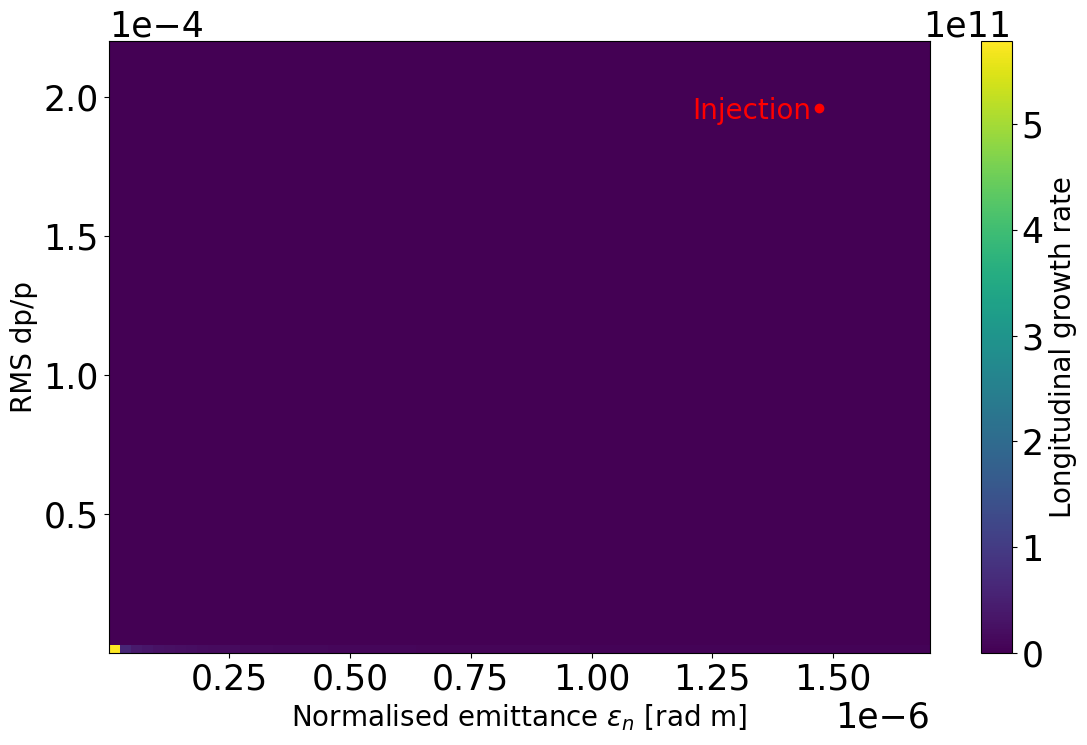

1it [00:00,  4.54it/s]


In [76]:
injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
injection_dp_p = 2e-4

for i,ion_loop in tqdm(enumerate([calcium])):

    data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
    # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
    # max_growth_rate=growth_rates_2d_x
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})

    # Plot the heatmap
    plt.imshow(growth_rates_2d_z, extent=[n_emitt_list.min(), n_emitt_list.max(), sig_delta_list[0], sig_delta_list[-1]],
               aspect='auto', origin='lower', cmap='viridis',norm=None)
       
    cbar = plt.colorbar()
    cbar.set_label('Longitudinal growth rate', fontsize=20)

    # Add injection point
    plt.scatter(0.98*injection_nemitt, 0.98*injection_dp_p, color='red', label='Injection Point')
    plt.text(0.97*injection_nemitt, 0.96*injection_dp_p, 'Injection', color='red', fontsize=20, ha='right')

    #contour = plt.contour(geo_epsx_list, sig_delta_list, growth_rates_2d_x, levels=[threshold], colors='red', linewidths=2)
    plt.xlabel('Normalised emittance $\\epsilon_n$ [rad m]', fontsize=20)
    plt.ylabel('RMS dp/p', fontsize=20)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.tight_layout()
    # plt.savefig('Lead_cooling_IBS_regime.png', dpi=300)
    plt.show()


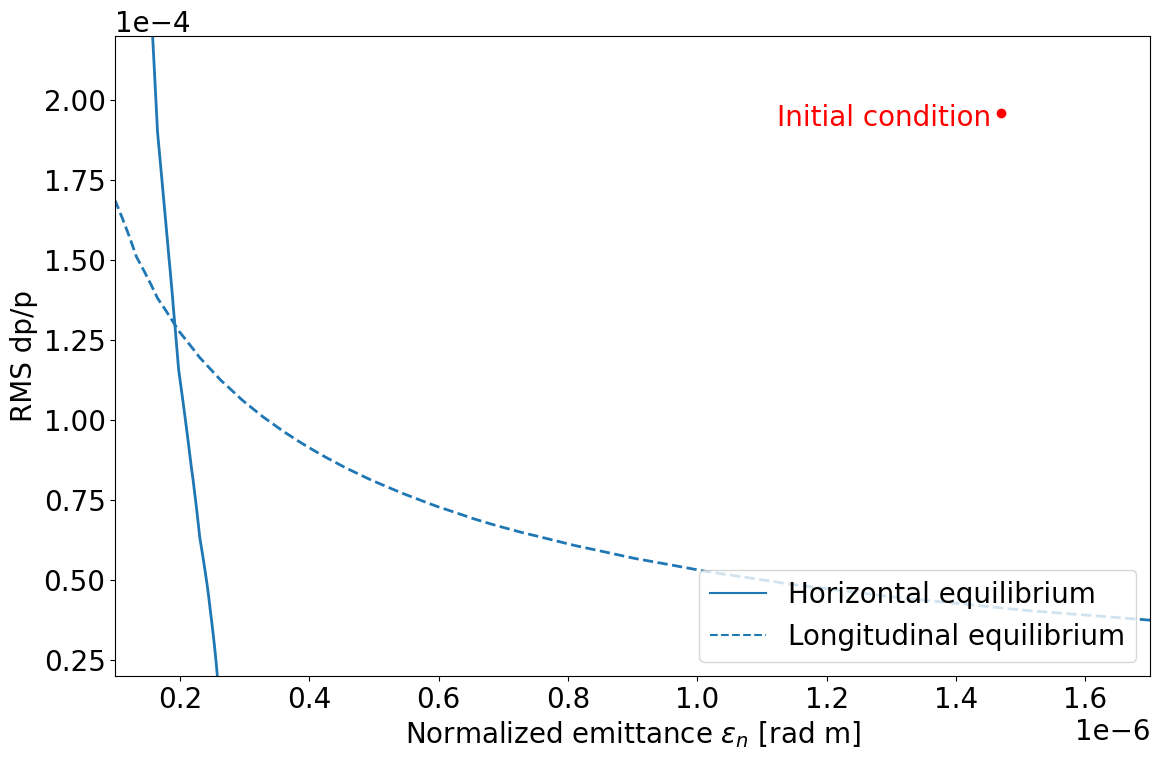

In [77]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Define custom legend handles with Line2D objects
legend_handles = [
    Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
]

fig=plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

for i, ion_loop in enumerate([calcium]):    
    data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')

    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
   
    loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
    transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
    longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
    #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
   
    threshold_transverse = -min(transverse_growth_rate_list)  # Set the threshold value
   
    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
                 colors=cycle[i], linewidths=2)

    min_transverse_index = np.argmin(transverse_growth_rate_list)
    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value
    
    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
                 colors=cycle[i], linestyles='--', linewidths=2)
    

plt.scatter(0.98*injection_nemitt, 0.98*injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.96*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')


plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.legend(handles=legend_handles, loc='lower right', fontsize='medium')


plt.tight_layout()

# # Save image
# image_name = 'horizontal_cooling.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'horizontal_cooling.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)



plt.show()

In [78]:
loaded_data.keys()

KeysView(NpzFile '../results/optimal_laser_x/Ca$^{17+}$.npz' with keys: transverse_growth_rate_list, longitudinal_growth_rate_emittance_list, longitudinal_growth_rate_dp_p_list, laser_x_list, nemitt...)

In [79]:
threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value

0it [00:00, ?it/s]

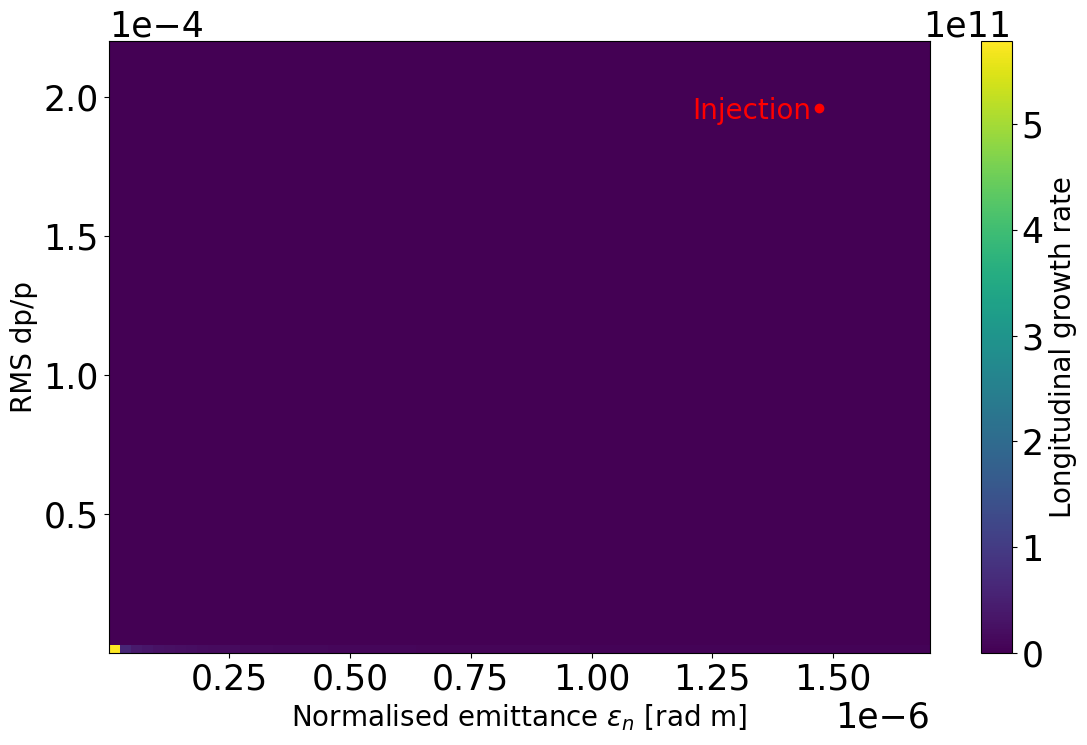

1it [00:00,  4.99it/s]


In [80]:
injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
injection_dp_p = 2e-4

for i,ion_loop in tqdm(enumerate([calcium])):

    data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')

    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
    # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
    # max_growth_rate=growth_rates_2d_x
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']

    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})

    # Plot the heatmap
    plt.imshow(growth_rates_2d_z, extent=[n_emitt_list.min(), n_emitt_list.max(), sig_delta_list[0], sig_delta_list[-1]],
               aspect='auto', origin='lower', cmap='viridis',norm=None)
       
    cbar = plt.colorbar()
    cbar.set_label('Longitudinal growth rate', fontsize=20)

    # Add injection point
    plt.scatter(0.98*injection_nemitt, 0.98*injection_dp_p, color='red', label='Injection Point')
    plt.text(0.97*injection_nemitt, 0.96*injection_dp_p, 'Injection', color='red', fontsize=20, ha='right')

    #contour = plt.contour(geo_epsx_list, sig_delta_list, growth_rates_2d_x, levels=[threshold], colors='red', linewidths=2)
    plt.xlabel('Normalised emittance $\\epsilon_n$ [rad m]', fontsize=20)
    plt.ylabel('RMS dp/p', fontsize=20)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.tight_layout()
    # plt.savefig('Lead_cooling_IBS_regime.png', dpi=300)
    plt.show()


zoom in on upper right corner

0it [00:00, ?it/s]

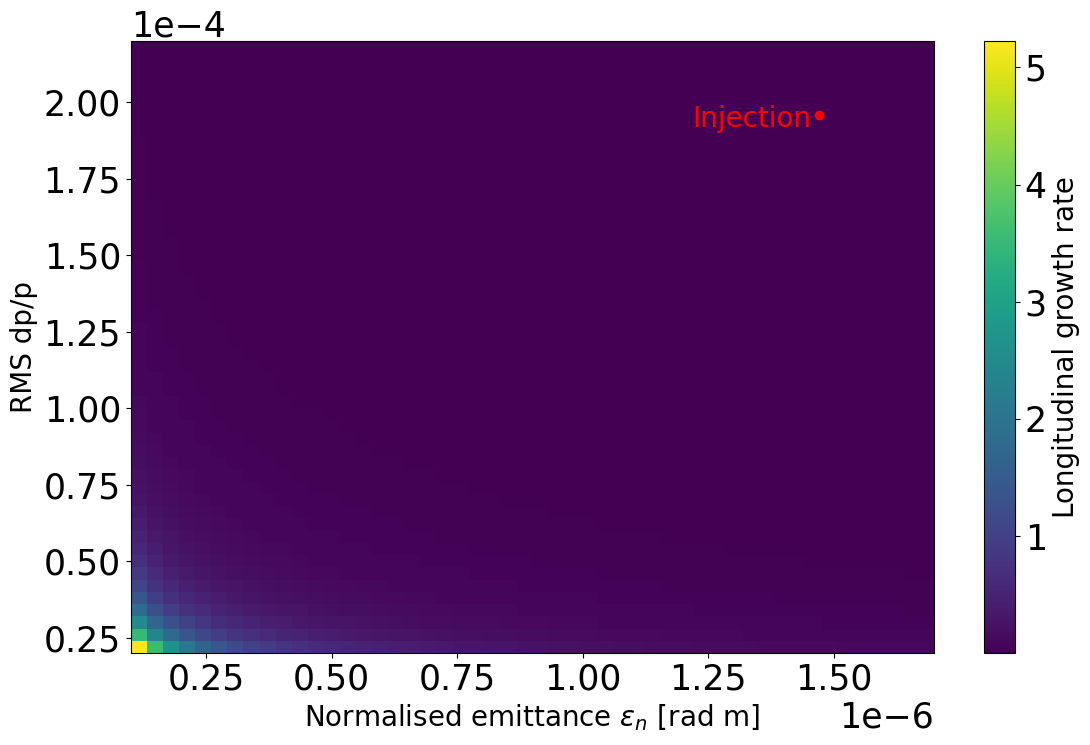

1it [00:00,  4.83it/s]


In [81]:
injection_nemitt = 1.5*1e-6 # m*rad (normalized emittance)
injection_dp_p = 2e-4

for i,ion_loop in tqdm(enumerate([calcium])):

    data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')

    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    #max_growth_rate=np.maximum(growth_rates_2d_x,growth_rates_2d_y,growth_rates_2d_z)
    # max_growth_rate = np.maximum.reduce([growth_rates_2d_x, growth_rates_2d_y, growth_rates_2d_z])
    # max_growth_rate=growth_rates_2d_x
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']

    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value

    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 25})

    # Plot the heatmap
    plt.imshow(growth_rates_2d_z, extent=[n_emitt_list.min(), n_emitt_list.max(), sig_delta_list[0], sig_delta_list[-1]],
               aspect='auto', origin='lower', cmap='viridis',norm=None)
       
    cbar = plt.colorbar()
    cbar.set_label('Longitudinal growth rate', fontsize=20)

    # Add injection point
    plt.scatter(0.98*injection_nemitt, 0.98*injection_dp_p, color='red', label='Injection Point')
    plt.text(0.97*injection_nemitt, 0.96*injection_dp_p, 'Injection', color='red', fontsize=20, ha='right')

    #contour = plt.contour(geo_epsx_list, sig_delta_list, growth_rates_2d_x, levels=[threshold], colors='red', linewidths=2)
    plt.xlabel('Normalised emittance $\\epsilon_n$ [rad m]', fontsize=20)
    plt.ylabel('RMS dp/p', fontsize=20)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    plt.tight_layout()
        # plt.savefig('Lead_cooling_IBS_regime.png', dpi=300)
    plt.show()


In [82]:
# print('transverse:',threshold_transverse)
# print('longitudinal:',threshold_longitudinal)


Draw arrows for cooling

compare IBS with full lattice

1it [00:01,  1.29s/it]

5
8
laser offset -1.4285714285714288 mm


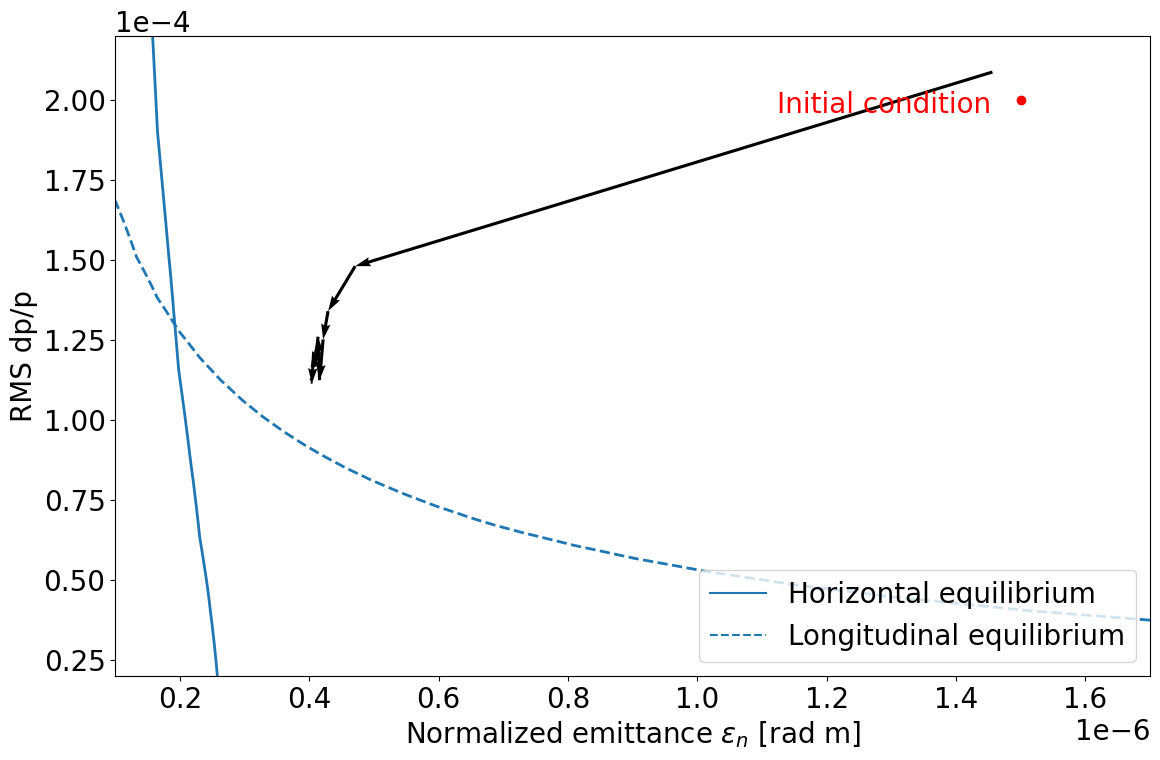

In [83]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
    lattice_results = np.load(f'results/{ion_loop.name}.npz')
    IBS_results = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_lattice = lattice_results['delta']
    emittance_x_lattice = lattice_results['emittance_x']
    time_lattice = lattice_results['time']
    rms_dp_p_lattice = np.std(delta_lattice, axis=1)
    core_width_lattice = core_width(lattice_results)

    index_closest_to_40 = np.argmin(np.abs(time_lattice - 40))

    emittance_x_values = emittance_x_lattice[:]
    rms_dp_p_values = rms_dp_p_lattice[:]
    
    # Plot the contour
    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']
    
    loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
    transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
    longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
    #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
    laser_x_list=loaded_data['laser_x_list']
   
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)
    print(min_transverse_index)
    print(min_longitudinal_index)

    #69  #74=0
    laser_position_index = min_transverse_index
    laser_offset = laser_x_list[laser_position_index]
    print('laser offset',laser_offset*1e3,'mm')
    threshold_longitudinal2 = -longitudinal_growth_rate_list[laser_position_index]  # Set the threshold value
    threshold_transverse2 = -(transverse_growth_rate_list[laser_position_index])  # Set the threshold value

    
    threshold_transverse = -min(transverse_growth_rate_list)  # Set the threshold value
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value
    

    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
                    colors=cycle[0], linewidths=2)   

    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
                    colors=cycle[0], linestyles='--', linewidths=2)
  
  
plot_quiver(emittance_x_lattice, rms_dp_p_lattice, time_lattice, 'black', label='Lattice') 
# Plotting the arrows on top completes, now let's adjust other settings        
injection_nemitt = 1.5*1e-6
injection_dp_p = 2e-4

plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        
plt.xlim([n_emitt_list[0], n_emitt_list[-1]])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.legend(handles=[
    Line2D([0], [0], linestyle='-', color=cycle[0],  label='Horizontal equilibrium '),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
          
], loc='lower right')


plt.tight_layout()

# # Save image
# image_name = 'calcium_no_ibs.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'calcium_no_ibs.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)


plt.show()

compare IBS with linear representation

0it [00:00, ?it/s]

1it [00:02,  2.54s/it]

5
8
laser offset -1.4285714285714288 mm


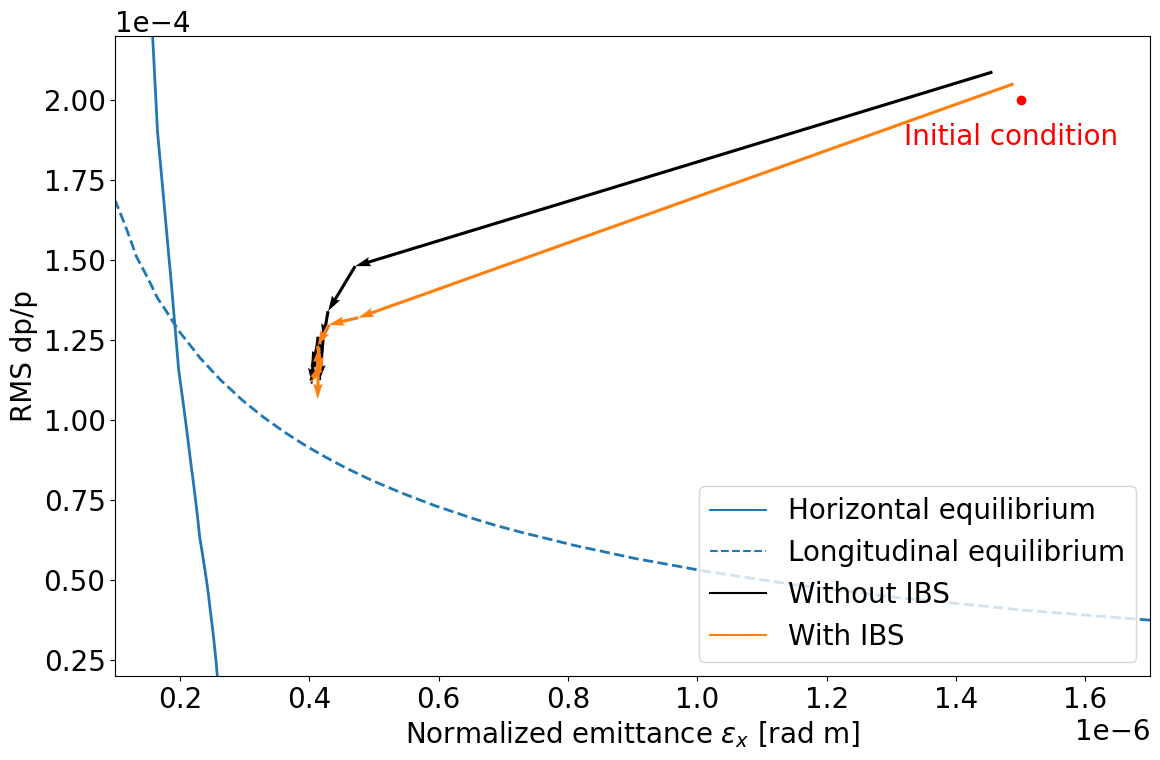

In [84]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([calcium])):    
    data = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
    lattice_results = np.load(f'results/{ion_loop.name}.npz')

    delta_lattice = lattice_results['delta']
    emittance_x_lattice = lattice_results['emittance_x']
    time_lattice = lattice_results['time']
    rms_dp_p_lattice = np.std(delta_lattice, axis=1)
    core_width_lattice = core_width(lattice_results)

    IBS_results = np.load(f'results/IBS/{ion_loop.name}.npz')

    delta_IBS = IBS_results['delta']
    emittance_x_IBS = IBS_results['emittance_x']
    time_IBS = IBS_results['time']
    rms_dp_p_IBS = np.std(delta_IBS, axis=1)
    core_width_IBS = core_width(IBS_results)

    index_closest_to_40 = np.argmin(np.abs(time_lattice - 40))

    # emittance_x = emittance_x[:]
    # rms_dp_p = rms_dp_p[:]
    
    # Plot the contour
    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']
    
    loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
    transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
    longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
    #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
    laser_x_list=loaded_data['laser_x_list']
   
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)
    print(min_transverse_index)
    print(min_longitudinal_index)

    #69  #74=0
    laser_position_index = 74
    laser_position_index=min_transverse_index
    laser_offset = laser_x_list[laser_position_index]
    print('laser offset',laser_offset*1e3,'mm')
    threshold_longitudinal2 = -longitudinal_growth_rate_list[laser_position_index]  # Set the threshold value
    threshold_transverse2 = -(transverse_growth_rate_list[laser_position_index])  # Set the threshold value

    
    threshold_transverse = -min(transverse_growth_rate_list)  # Set the threshold value
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value
    # threshold_longitudinal=-0.4

    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
                    colors=cycle[0], linewidths=2)   

    plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
                    colors=cycle[0], linestyles='--', linewidths=2)
    

    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse2, np.inf],
    #                 colors=cycle[2], linewidths=2)   

    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal2],
    #                 colors=cycle[2], linestyles='--', linewidths=2)

    plot_quiver(emittance_x_lattice, rms_dp_p_lattice, time_lattice, 'black', label='Lattice') 
    plot_quiver(emittance_x_IBS, rms_dp_p_IBS, time_IBS, 'C1', label='IBS') 
 

# Plotting the arrows on top completes, now let's adjust other settings        
injection_nemitt =1.5*1e-6
injection_dp_p = 2e-4

plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
plt.text(1.1*injection_nemitt, 0.93*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([n_emitt_list[0], n_emitt_list[-1]])
plt.xlabel('Normalized emittance $\\epsilon_x$ [rad m]', fontsize=20)
plt.ylabel('RMS dp/p', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.legend(handles=[
    Line2D([0], [0], linestyle='-', color=cycle[0], label='Horizontal equilibrium'),
    Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
    Line2D([0], [0], linestyle='-', color='black', label='Without IBS'),
    Line2D([0], [0], linestyle='-', color=cycle[1], label='With IBS'),
], loc='lower right')


plt.tight_layout()


# # Save image
# image_name = 'calcium_xsuite_ibs_vs_no_ibs.pdf'
# save_location = os.path.join(save_dir, image_name)
# plt.savefig(save_location, dpi=300, bbox_inches='tight')
# # Define your pickle filename
# pickle_filename = 'calcium_xsuite_ibs_vs_no_ibs.pkl'
# pickle_file_path = os.path.join(save_dir, pickle_filename)
# # Save the figure object 'fig' using pickle
# with open(pickle_file_path, 'wb') as f:
#     pickle.dump(fig, f)


plt.show()

also plot arrow with smaller initial emittances

changing cooling rate

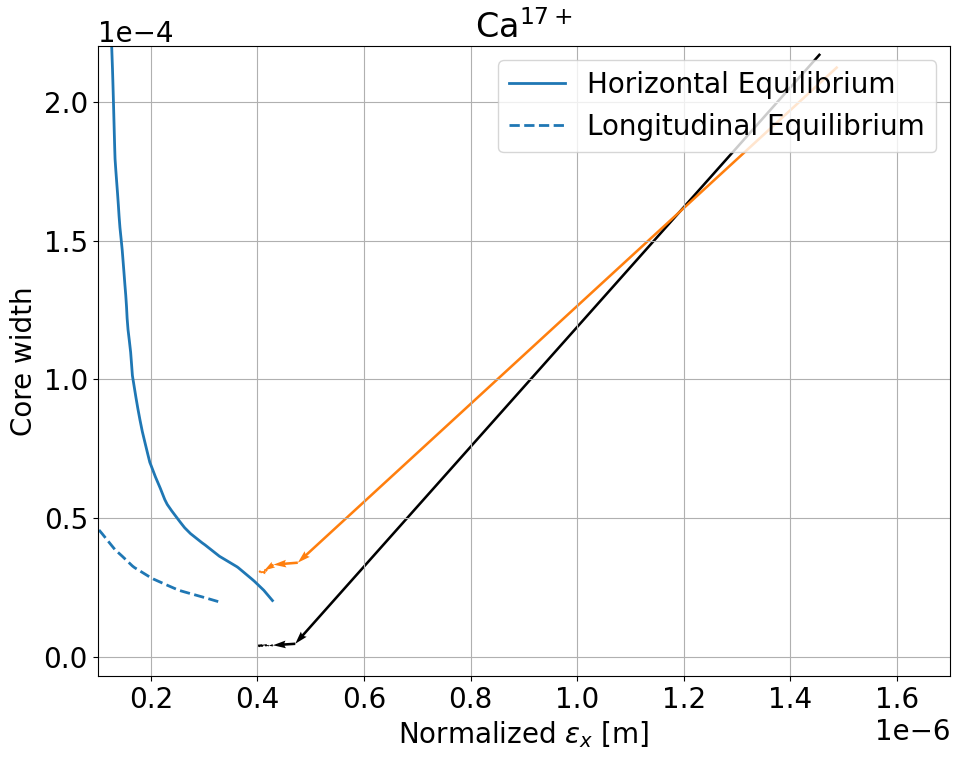

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import matplotlib.lines as mlines

ion_loop = calcium  # adjust as needed

# --------------------------------------------------
# 1) Load & transpose your cooling‐rate arrays
# --------------------------------------------------
data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
# longitudinal:
cool_long = data_cool['longitudinal_emittance_growth_rate_array'].T
# horizontal (swap in your correct key):
cool_horiz = data_cool['transverse_cooling_rate_array'].T

n_em_cool = data_cool['n_emitt_list']
sd_cool   = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
ibs_long = data_ibs['growth_rates_2d_z']
ibs_horiz= data_ibs['growth_rates_2d_x']

n_em_ibs = data_ibs['n_emitt_list']
sd_ibs   = data_ibs['sig_delta_list']

# --------------------------------------------------
# 3) Build a common (overlapping) grid
# --------------------------------------------------
n_min = max(n_em_cool[0], n_em_ibs[0])
n_max = min(n_em_cool[-1], n_em_ibs[-1])
s_min = max(sd_cool[0],   sd_ibs[0])
s_max = min(sd_cool[-1],   sd_ibs[-1])

n_pts = 50
n_common = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, n_pts)

# --------------------------------------------------
# 4) Interpolate both planes
# --------------------------------------------------
# longitudinal
interp_long_c = RegularGridInterpolator((sd_cool, n_em_cool), cool_long,
                                        bounds_error=False, fill_value=None)
interp_long_i = RegularGridInterpolator((sd_ibs,  n_em_ibs),  ibs_long,
                                        bounds_error=False, fill_value=None)
# horizontal
interp_h_c = RegularGridInterpolator((sd_cool, n_em_cool), cool_horiz,
                                     bounds_error=False, fill_value=None)
interp_h_i = RegularGridInterpolator((sd_ibs,  n_em_ibs),  ibs_horiz,
                                     bounds_error=False, fill_value=None)

N, S = np.meshgrid(n_common, s_common)
pts = np.vstack([S.ravel(), N.ravel()]).T

# evaluate & reshape
long_on = interp_long_c(pts).reshape(S.shape) + interp_long_i(pts).reshape(S.shape)
horiz_on= interp_h_c(pts).reshape(S.shape)      + interp_h_i(pts).reshape(S.shape)

# --------------------------------------------------
# 5) Plot everything together
# --------------------------------------------------
plt.figure(figsize=(10, 8))

# (optional) your quiver fields here
plot_quiver(emittance_x_lattice, core_width_lattice, time_lattice, 'black', 'Lattice without IBS')
plot_quiver(emittance_x_IBS, core_width_IBS, time_IBS, cycle[1], 'With IBS')
#plot_quiver(emittance_x_IBS_small, core_width_IBS_small, time_IBS_small, cycle[1], 'With IBS (small emittance)')
#plot_quiver(emittance_x_IBS_small_dp_p, core_width_IBS_small_dp_p, time_IBS_small_dp_p, cycle[1], 'With IBS (small dp/p)')
# horizontal equilibrium (solid black)
plt.contour(
    n_common, s_common, horiz_on,
    levels=[0],
    colors='C0', linestyles='-', linewidths=2
)

# longitudinal equilibrium (dashed black)
plt.contour(
    n_common, s_common, long_on,
    levels=[0],
    colors='C0', linestyles='--', linewidths=2
)

# legend via proxy artists
h_line = mlines.Line2D([], [], color='C0', linestyle='-',  linewidth=2,
                       label='Horizontal Equilibrium')
l_line = mlines.Line2D([], [], color='C0', linestyle='--', linewidth=2,
                       label='Longitudinal Equilibrium')
plt.legend(handles=[h_line, l_line], loc='upper right')

plt.xlabel(r'Normalized $\varepsilon_{x}$ [m]')
plt.ylabel(r'RMS $\delta p/p$')
plt.ylabel('Core width')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title(f'{ion_loop.name}')
plt.grid(True)
plt.tight_layout()
plt.show()


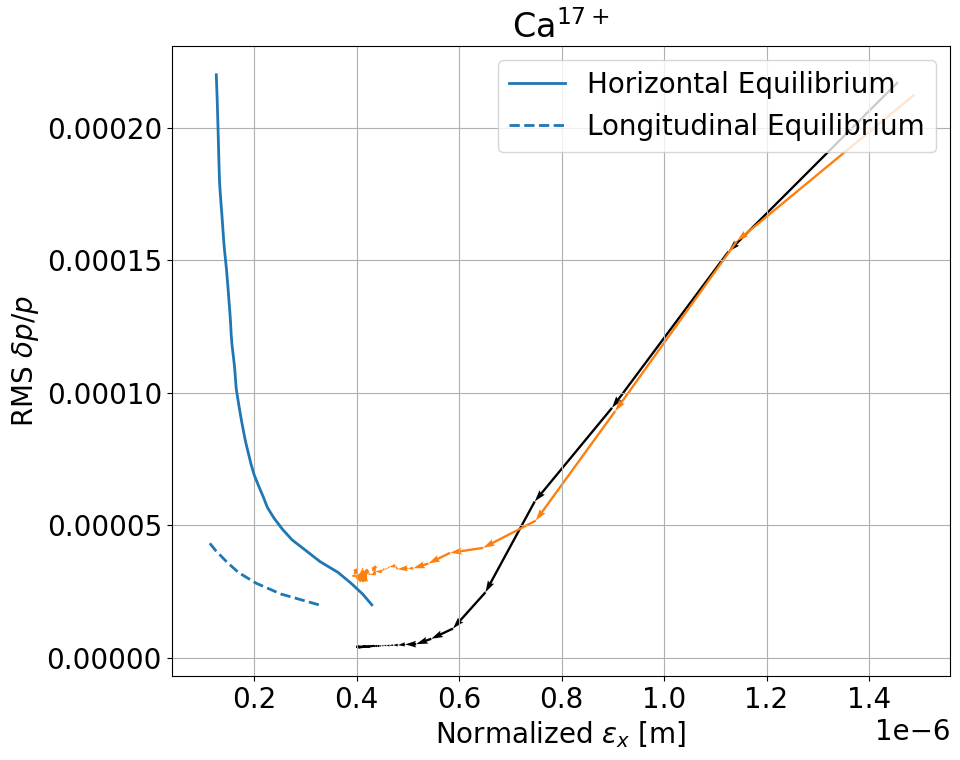

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# --- replace this with your actual ion‐species object or loop variable ---
ion_loop = calcium  

# --------------------------------------------------
# 1) Load & transpose your cooling‐rate arrays
# --------------------------------------------------
data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long  = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool  = data_cool['n_emitt_list']
sd_cool    = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs   = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
ibs_long   = data_ibs['growth_rates_2d_z']
ibs_horiz  = data_ibs['growth_rates_2d_x']
n_em_ibs   = data_ibs['n_emitt_list']
sd_ibs     = data_ibs['sig_delta_list']

# --------------------------------------------------
# 3) Build the OVERLAP grid (only where both data sets exist)
# --------------------------------------------------
n_min = max(n_em_cool[0],  n_em_ibs[0])
n_max = min(n_em_cool[-1], n_em_ibs[-1])
s_min = max(sd_cool[0],    sd_ibs[0])
s_max = min(sd_cool[-1],   sd_ibs[-1])

n_pts = 50
n_common = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, n_pts)

# --------------------------------------------------
# 4) Create interpolators (no extrapolation: out‐of‐bounds → NaN)
# --------------------------------------------------
interp_h_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_horiz,
    bounds_error=False, fill_value=None
)
interp_h_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_horiz,
    bounds_error=False, fill_value=None
)
interp_l_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_long,
    bounds_error=False, fill_value=None
)
interp_l_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_long,
    bounds_error=False, fill_value=None
)

# --------------------------------------------------
# 5) Define net‐rate functions for root‐finding
# --------------------------------------------------
def net_h(eps, s):
    # horizontal net rate at (eps, s)
    return float(interp_h_c((s, eps))) + float(interp_h_i((s, eps)))

def net_l(eps, s):
    # longitudinal net rate at (eps, s)
    return float(interp_l_c((s, eps))) + float(interp_l_i((s, eps)))

# --------------------------------------------------
# 6) Find one zero‐crossing per delta (s_common) with brentq
# --------------------------------------------------
eq_h = np.full_like(s_common, np.nan)
eq_l = np.full_like(s_common, np.nan)

for i, s in enumerate(s_common):
    # bracket endpoints
    a, b = n_min, n_max

    # horizontal: try to find any root in [a, b]
    try:
        if np.sign(net_h(a, s)) != np.sign(net_h(b, s)):
            eq_h[i] = brentq(net_h, a, b, args=(s,))
    except (ValueError, RuntimeError):
        eq_h[i] = np.nan

    # longitudinal: try to find any root in [a, b]
    try:
        if np.sign(net_l(a, s)) != np.sign(net_l(b, s)):
            eq_l[i] = brentq(net_l, a, b, args=(s,))
    except (ValueError, RuntimeError):
        eq_l[i] = np.nan

# --------------------------------------------------
# 7) Plot everything
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
num_segments=100
# --- your quiver fields go here ---
plot_quiver(emittance_x_lattice, core_width_lattice, time_lattice,num_segments=num_segments,
            color='black', label='Lattice without IBS')
plot_quiver(emittance_x_IBS,     core_width_IBS,     time_IBS,
            color='C1',       label='With IBS',num_segments=num_segments)

# equilibrium curves:
ax.plot(eq_h, s_common,  '-',  color='C0', linewidth=2,
        label='Horizontal Equilibrium')
ax.plot(eq_l, s_common,  '--', color='C0', linewidth=2,
        label='Longitudinal Equilibrium')

ax.legend(loc='upper right')
ax.set_xlabel(r'Normalized $\varepsilon_{x}$ [m]')
ax.set_ylabel(r'RMS $\delta p/p$')
ax.ticklabel_format(axis='y', style='plain')  # full tick labels
ax.set_title(f'{ion_loop.name}')
ax.grid(True)
plt.tight_layout()
plt.show()


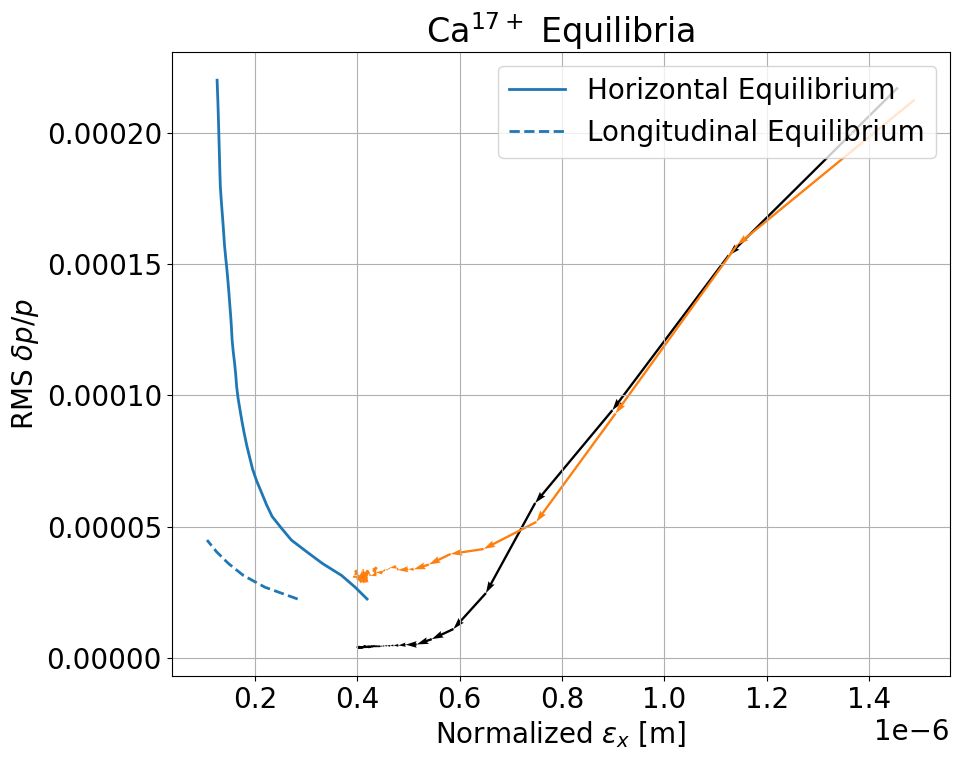

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# --- replace this with your actual ion‐species object or loop variable ---
ion_loop = calcium  

# --------------------------------------------------
# 1) Load & transpose your cooling‐rate arrays
# --------------------------------------------------
data_cool = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long  = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool  = data_cool['n_emitt_list']
sd_cool    = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs   = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
ibs_long   = data_ibs['growth_rates_2d_z']
ibs_horiz  = data_ibs['growth_rates_2d_x']
n_em_ibs   = data_ibs['n_emitt_list']
sd_ibs     = data_ibs['sig_delta_list']

# --------------------------------------------------
# 3) Build the FULL joint grid (union of both ranges)
# --------------------------------------------------
n_min = min(n_em_cool[0],  n_em_ibs[0])
n_max = max(n_em_cool[-1], n_em_ibs[-1])
s_min = min(sd_cool[0],    sd_ibs[0])
s_max = max(sd_cool[-1],   sd_ibs[-1])

n_pts = 50
s_pts = 50
n_common = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, s_pts)

# --------------------------------------------------
# 4) Create interpolators (out‐of‐bounds → NaN)
# --------------------------------------------------
interp_h_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_horiz,
    bounds_error=False, fill_value=np.nan
)
interp_h_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_horiz,
    bounds_error=False, fill_value=np.nan
)
interp_l_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_long,
    bounds_error=False, fill_value=np.nan
)
interp_l_i = RegularGridInterpolator(
    (sd_ibs, n_em_ibs), ibs_long,
    bounds_error=False, fill_value=np.nan
)

# --------------------------------------------------
# 5) Define net‐rate functions for root‐finding
# --------------------------------------------------
def net_h(eps, s):
    """Horizontal net rate at (eps, s)."""
    val_c = interp_h_c((s, eps))
    val_i = interp_h_i((s, eps))
    return float(val_c) + float(val_i)

def net_l(eps, s):
    """Longitudinal net rate at (eps, s)."""
    val_c = interp_l_c((s, eps))
    val_i = interp_l_i((s, eps))
    return float(val_c) + float(val_i)

# --------------------------------------------------
# 6) Find one zero‐crossing per delta (s_common) with a scan + brentq
# --------------------------------------------------
eq_h = np.full_like(s_common, np.nan, dtype=float)
eq_l = np.full_like(s_common, np.nan, dtype=float)

# finer eps grid for bracketing
eps_scan = np.linspace(n_min, n_max, 200)

for i, s in enumerate(s_common):
    # Horizontal
    for j in range(len(eps_scan) - 1):
        a, b = eps_scan[j], eps_scan[j+1]
        fa, fb = net_h(a, s), net_h(b, s)
        # skip if either side is NaN or no sign change
        if np.isnan(fa) or np.isnan(fb):
            continue
        if np.sign(fa) != np.sign(fb):
            try:
                eq_h[i] = brentq(net_h, a, b, args=(s,))
            except Exception:
                eq_h[i] = np.nan
            break

    # Longitudinal
    for j in range(len(eps_scan) - 1):
        a, b = eps_scan[j], eps_scan[j+1]
        fa, fb = net_l(a, s), net_l(b, s)
        if np.isnan(fa) or np.isnan(fb):
            continue
        if np.sign(fa) != np.sign(fb):
            try:
                eq_l[i] = brentq(net_l, a, b, args=(s,))
            except Exception:
                eq_l[i] = np.nan
            break

# --------------------------------------------------
# 7) Plot everything
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# your quiver fields
plot_quiver(emittance_x_lattice, core_width_lattice, time_lattice,
            num_segments=100, color='black', label='Lattice without IBS')
plot_quiver(emittance_x_IBS,     core_width_IBS,     time_IBS,
            color='C1',            label='With IBS', num_segments=100)

# equilibrium curves
ax.plot(eq_h, s_common,  '-',  color='C0', linewidth=2,
        label='Horizontal Equilibrium')
ax.plot(eq_l, s_common,  '--', color='C0', linewidth=2,
        label='Longitudinal Equilibrium')

ax.legend(loc='upper right')
ax.set_xlabel(r'Normalized $\varepsilon_{x}$ [m]')
ax.set_ylabel(r'RMS $\delta p/p$')
ax.ticklabel_format(axis='y', style='plain')  # full tick labels
ax.set_title(f'{ion_loop.name} Equilibria')
ax.grid(True)
plt.tight_layout()
plt.show()


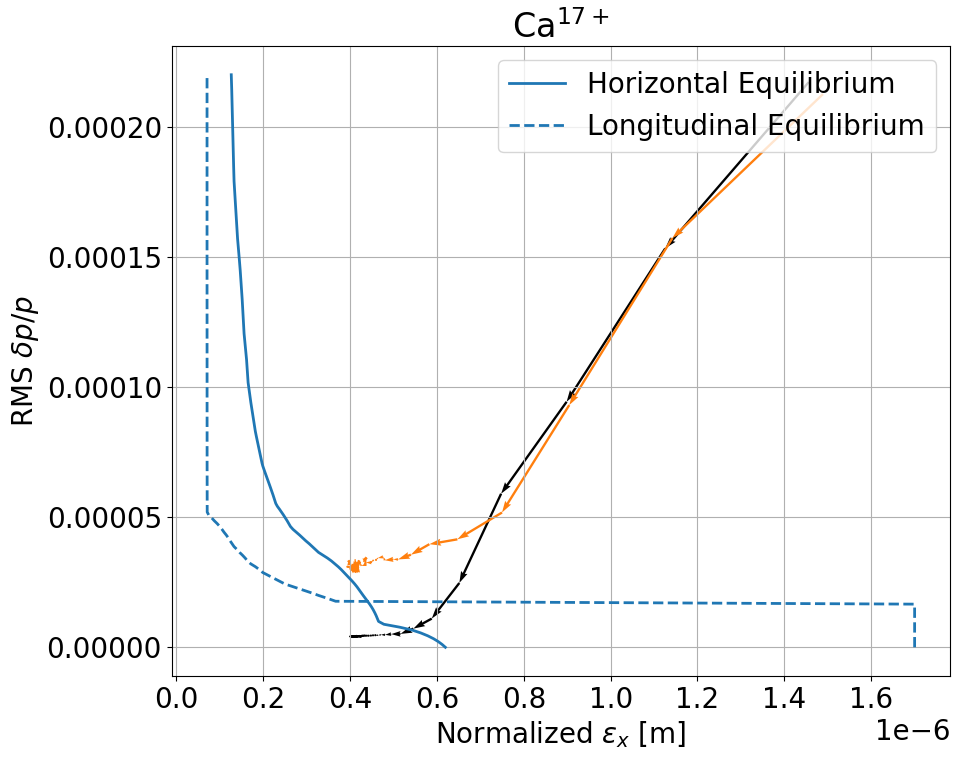

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# --- replace this with your actual ion‐species object or loop variable ---
ion_loop = calcium  

# --------------------------------------------------
# 1) Load & transpose your cooling‐rate arrays
# --------------------------------------------------
data_cool  = np.load(f'../results/cooling_rate_scan/{ion_loop.name}.npz')
cool_long  = data_cool['longitudinal_emittance_growth_rate_array'].T
cool_horiz = data_cool['transverse_cooling_rate_array'].T
n_em_cool  = data_cool['n_emitt_list']
sd_cool    = data_cool['sig_delta_list']

# --------------------------------------------------
# 2) Load your IBS‐rate arrays
# --------------------------------------------------
data_ibs   = np.load(f'../results/IBS_bunched/backup/{ion_loop.name}.npz')
ibs_long   = data_ibs['growth_rates_2d_z']
ibs_horiz  = data_ibs['growth_rates_2d_x']
n_em_ibs   = data_ibs['n_emitt_list']
sd_ibs     = data_ibs['sig_delta_list']

# --------------------------------------------------
# 3) Build the UNION grid (cover all data ranges)
# --------------------------------------------------
n_pts = 200
n_min = min(n_em_cool[0],   n_em_ibs[0])
n_max = max(n_em_cool[-1],  n_em_ibs[-1])
s_min = min(sd_cool[0],     sd_ibs[0])
s_max = max(sd_cool[-1],    sd_ibs[-1])

n_common = np.linspace(n_min, n_max, n_pts)
s_common = np.linspace(s_min, s_max, n_pts)

# --------------------------------------------------
# 4) Create interpolators (NaN outside original bounds)
# --------------------------------------------------
interp_h_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_horiz,
    bounds_error=False, fill_value=None
)
interp_h_i = RegularGridInterpolator(
    (sd_ibs,   n_em_ibs),  ibs_horiz,
    bounds_error=False, fill_value=None
)
interp_l_c = RegularGridInterpolator(
    (sd_cool, n_em_cool), cool_long,
    bounds_error=False, fill_value=None
)
interp_l_i = RegularGridInterpolator(
    (sd_ibs,   n_em_ibs),  ibs_long,
    bounds_error=False, fill_value=None
)

# --------------------------------------------------
# 5) Define net‐rate functions for root‐finding
# --------------------------------------------------
def net_h(eps, s):
    return float(interp_h_c((s, eps))) + float(interp_h_i((s, eps)))

def net_l(eps, s):
    return float(interp_l_c((s, eps))) + float(interp_l_i((s, eps)))

# --------------------------------------------------
# 6) Find (or clamp) one zero‐crossing per Δp/p
# --------------------------------------------------
eq_h = np.full_like(s_common, np.nan)
eq_l = np.full_like(s_common, np.nan)

for i, s in enumerate(s_common):
    a, b = n_min, n_max
    fa, fb = net_h(a, s), net_h(b, s)
    if np.sign(fa) * np.sign(fb) < 0:
        eq_h[i] = brentq(net_h, a, b, args=(s,))
    else:
        # clamp to whichever boundary has smaller |net_h|
        eq_h[i] = a if abs(fa) < abs(fb) else b

    fa, fb = net_l(a, s), net_l(b, s)
    if np.sign(fa) * np.sign(fb) < 0:
        eq_l[i] = brentq(net_l, a, b, args=(s,))
    else:
        # clamp to whichever boundary has smaller |net_l|
        eq_l[i] = a if abs(fa) < abs(fb) else b

# --------------------------------------------------
# 7) Plot everything
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
num_segments = 100

# your quiver fields
plot_quiver(emittance_x_lattice, core_width_lattice, time_lattice,
            num_segments=num_segments, color='black', label='Lattice without IBS')
plot_quiver(emittance_x_IBS, core_width_IBS, time_IBS,
            num_segments=num_segments, color='C1', label='With IBS')

# equilibrium curves
ax.plot(eq_h, s_common, '-',  color='C0', linewidth=2,
        label='Horizontal Equilibrium')
ax.plot(eq_l, s_common, '--', color='C0', linewidth=2,
        label='Longitudinal Equilibrium')

ax.legend(loc='upper right')
ax.set_xlabel(r'Normalized $\varepsilon_{x}$ [m]')
ax.set_ylabel(r'RMS $\delta p/p$')
ax.ticklabel_format(axis='y', style='plain')
ax.set_title(f'{ion_loop.name}')
ax.grid(True)

plt.tight_layout()
plt.show()


In [100]:
emittance_x_IBS[-1]

np.float64(4.11678509489011e-07)

look at phase spaces

In [89]:
data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
linear_results = np.load(f'../results/transverse/{ion_loop.name}.npz')

delta_linear = linear_results['delta']
emittance_x_linear = linear_results['emittance_x']
time_linear = linear_results['time']
rms_dp_p_linear = np.std(delta_linear, axis=1)
emittance_x_linear = emittance_x_linear[:]
rms_dp_p__linear = rms_dp_p_linear[:]

index_closest_to_40 = np.argmin(np.abs(time_linear - 40))

#load IBS results
IBS_results = np.load(f'results/IBS/{ion_loop.name}.npz')

delta_IBS = IBS_results['delta']
emittance_x_IBS = IBS_results['emittance_x']
time_IBS = IBS_results['time']
rms_dp_p_IBS = np.std(delta_IBS, axis=1)

x_IBS = IBS_results['x']
px_IBS = IBS_results['px']

#load IBS results small emittance
#IBS_small_results = np.load(f'results/IBS/{ion_loop.name}_small.npz')

# delta_IBS_small = IBS_small_results['delta']
# emittance_x_IBS_small = IBS_small_results['emittance_x']
# time_IBS_small = IBS_small_results['time']
# rms_dp_p_IBS_small = np.std(delta_IBS_small, axis=1)      

all_data = np.concatenate(delta_IBS)
x_min, x_max = all_data.min(), all_data.max()

bins = 50

# Determine the maximum y value across all histograms
hist_counts = [np.histogram(data, bins=bins)[0] for data in delta_linear]
y_max = max(max(counts) for counts in hist_counts)

# Function to calculate RMS of the core
def core_rms(delta, percentile=95):
    lower_bound = np.percentile(delta, (100 - percentile) / 2)
    upper_bound = np.percentile(delta, 100 - (100 - percentile) / 2)
    core_values = delta[(delta >= lower_bound) & (delta <= upper_bound)]
    return np.std(core_values)

rms_dp_p_IBS_core = np.array([core_rms(delta) for delta in delta_IBS])
rms_dp_p_linear_core = np.array([core_rms(delta) for delta in delta_linear])

# Function to plot histograms at a given turn and overlay RMS as width
def plot_histogram(turn):
    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 20})
    plt.title(f'With IBS: Time {time_IBS[turn]:.1f}')
    
    # Plot histograms
    plt.hist(delta_IBS[turn], bins=bins, histtype='step', label='With IBS')
    plt.hist(delta_linear[turn], bins=bins, histtype='step', label='Without IBS')
    
    # Plot RMS as vertical lines
    plt.axvline(x=rms_dp_p_IBS_core[turn], color='blue', linestyle='--', label='RMS With IBS')
    plt.axvline(x=-rms_dp_p_IBS_core[turn], color='blue', linestyle='--')
    plt.axvline(x=rms_dp_p_linear_core[turn], color='orange', linestyle='--', label='RMS Without IBS')
    plt.axvline(x=-rms_dp_p_linear_core[turn], color='orange', linestyle='--')
    
    # plt.xlim(x_min, x_max)  # Set the x-axis limits
    # plt.ylim(0, y_max)  # Set the y-axis limits
    plt.ylabel('Count')
    plt.xlabel('dp/p ')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

interact(plot_histogram, turn=IntSlider(min=0, max=len(time_lattice)-1, step=1, value=0))


interactive(children=(IntSlider(value=0, description='turn', max=10016), Output()), _dom_classes=('widget-inte…

<function __main__.plot_histogram(turn)>

In [90]:
data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
linear_results = np.load(f'../results/transverse/{ion_loop.name}.npz')

delta_linear = linear_results['delta']
zeta_linear=linear_results['zeta']
emittance_x_linear = linear_results['emittance_x']
time_linear = linear_results['time']
rms_dp_p_linear = np.std(delta_linear, axis=1)
emittance_x_linear = emittance_x_linear[:]
rms_dp_p__linear = rms_dp_p_linear[:]

index_closest_to_40 = np.argmin(np.abs(time_linear - 40))

#load IBS results
IBS_results = np.load(f'results/IBS/{ion_loop.name}.npz')

delta_IBS = IBS_results['delta']
emittance_x_IBS = IBS_results['emittance_x']
time_IBS = IBS_results['time']
rms_dp_p_IBS = np.std(delta_IBS, axis=1)

x_IBS = IBS_results['x']
px_IBS = IBS_results['px']

#load IBS results small emittance
#IBS_small_results = np.load(f'results/IBS/{ion_loop.name}_small.npz')

# delta_IBS_small = IBS_small_results['delta']
# emittance_x_IBS_small = IBS_small_results['emittance_x']
# time_IBS_small = IBS_small_results['time']
# rms_dp_p_IBS_small = np.std(delta_IBS_small, axis=1)      

all_data = np.concatenate(delta_IBS)
x_min, x_max = all_data.min(), all_data.max()

bins = 50

# Determine the maximum y value across all histograms
hist_counts = [np.histogram(data, bins=bins)[0] for data in delta_linear]
y_max = max(max(counts) for counts in hist_counts)

# Function to calculate RMS of the core
def core_rms(delta, percentile=100):
    lower_bound = np.percentile(delta, (100 - percentile) / 2)
    upper_bound = np.percentile(delta, 100 - (100 - percentile) / 2)
    core_values = delta[(delta >= lower_bound) & (delta <= upper_bound)]
    return np.std(core_values)

rms_dp_p_IBS_core = np.array([core_rms(delta) for delta in delta_IBS])
rms_dp_p_linear_core = np.array([core_rms(delta) for delta in delta_linear])

# Function to plot histograms at a given turn and overlay RMS as width
def plot_histogram(turn):
    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 20})
    plt.title(f'With IBS: Time {time_IBS[turn]:.1f}')
    
    # Plot histograms
    plt.hist(delta_IBS[turn], bins=bins, histtype='step', label='With IBS')
    plt.hist(delta_linear[turn], bins=bins, histtype='step', label='Without IBS')
    
    # Plot RMS as vertical lines
    plt.axvline(x=np.std(delta_linear[turn]), color='blue', linestyle='--', label='RMS With IBS')
    plt.axvline(x=-np.std(delta_linear[turn]), color='blue', linestyle='--')
    plt.axvline(x=np.std(delta_IBS[turn]), color='orange', linestyle='--', label='RMS Without IBS')
    plt.axvline(x=-np.std(delta_IBS[turn]), color='orange', linestyle='--')
    
    plt.xlim(x_min, x_max)  # Set the x-axis limits
    plt.ylim(0, y_max)  # Set the y-axis limits
    plt.ylabel('Count')
    plt.xlabel('dp/p ')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

interact(plot_histogram, turn=IntSlider(min=0, max=len(time_lattice)-1, step=1, value=0))


interactive(children=(IntSlider(value=0, description='turn', max=10016), Output()), _dom_classes=('widget-inte…

<function __main__.plot_histogram(turn)>

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# Compute global limits from all data
all_data_x = np.concatenate(zeta_linear)  # Assuming `zeta_linear` is a list/array of arrays
all_data_y = np.concatenate(delta_linear)  # Assuming `delta_linear` is a list/array of arrays

x_min, x_max = all_data_x.min(), all_data_x.max()
y_min, y_max = all_data_y.min(), all_data_y.max()

def plot_histogram(turn):
    plt.figure(figsize=(12, 8))
    plt.rcParams.update({'font.size': 20})
    
    plt.title(f'With IBS: Time {time_IBS[turn]:.1f}')
    
    # Plot scatter data
    plt.scatter(zeta_linear[turn], delta_linear[turn])
    
    # Set consistent axis limits
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    plt.xlabel('zeta (longitudinal position)')  # Update xlabel for clarity
    plt.ylabel('dp/p (momentum deviation)')
    
    plt.tight_layout()
    plt.show()

# Interactive plot
interact(plot_histogram, turn=IntSlider(min=0, max=len(time_IBS)-1, step=1, value=0))


interactive(children=(IntSlider(value=0, description='turn', max=10016), Output()), _dom_classes=('widget-inte…

<function __main__.plot_histogram(turn)>

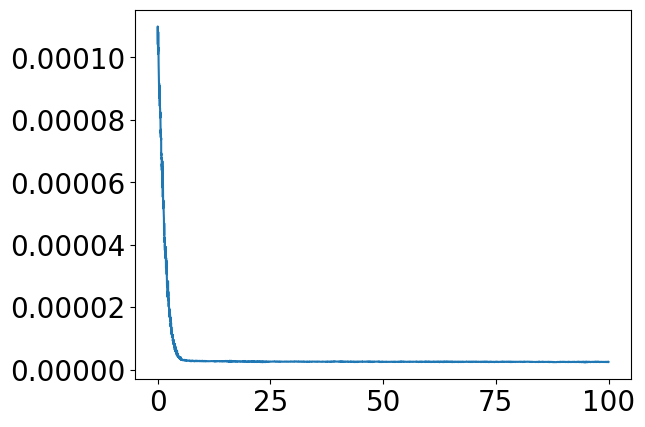

In [92]:
# Function to calculate RMS of the core
def core_rms(delta, percentile=70):
    lower_bound = np.percentile(delta, (100 - percentile) / 2)
    upper_bound = np.percentile(delta, 100 - (100 - percentile) / 2)
    core_values = delta[(delta >= lower_bound) & (delta <= upper_bound)]
    return np.std(core_values)

rms_dp_p_IBS_core = np.array([core_rms(delta) for delta in delta_IBS])
rms_dp_p_linear_core = np.array([core_rms(delta) for delta in delta_linear])

plt.figure()
plt.plot(time_lattice,rms_dp_p_linear_core)
plt.show()

find bunch length and momentum spread at the end of the tracking

In [93]:
growth_rates_2d_z.shape
#delta, n_emitt
target_nemitt = 1.5e-6
target_sig_delta = 2e-4

def find_longitudinal_growth_rate(target_nemitt, target_sig_delta):
       
    emitt_index = np.abs(n_emitt_list - target_nemitt).argmin()
    sig_delta_index = np.abs(sig_delta_list - target_sig_delta).argmin()
    growth_rate = growth_rates_2d_z[emitt_index,sig_delta_index]
    print(growth_rate)

find_longitudinal_growth_rate(target_nemitt, target_sig_delta)


0.0009114933916475393


In [94]:
threshold_longitudinal

np.float64(0.029226287254179285)

In [95]:
def calculate_longitudinal_emittance(zeta, delta):
    """
    Calculate the longitudinal emittance for each turn.

    Parameters:
    zeta (numpy.ndarray): 2D array where each row represents a turn and each column represents a particle's zeta value.
    delta (numpy.ndarray): 2D array where each row represents a turn and each column represents a particle's delta value.

    Returns:
    numpy.ndarray: 1D array containing the longitudinal emittance for each turn.
    """
    # Calculate the mean of zeta and delta for each turn
    mean_z = np.mean(zeta, axis=1)
    mean_delta = np.mean(delta, axis=1)

    # Calculate the standard deviation of zeta and delta for each turn
    sigma_z = np.std(zeta, axis=1)
    sigma_delta = np.std(delta, axis=1)

    # Calculate the covariance between zeta and delta for each turn
    cov_z_delta = np.mean(zeta * delta, axis=1) - mean_z * mean_delta

    # Calculate longitudinal emittance for each turn
    longitudinal_emittance = np.sqrt(sigma_z**2 * sigma_delta**2 - cov_z_delta**2)

    return longitudinal_emittance

look at longitudinal emittance instead of rms dp/p

In [96]:
linear_results = np.load(f'results/{ion_loop.name}.npz')

delta = linear_results['delta']
zeta=linear_results['zeta']
emittance_x = linear_results['emittance_x']
time = linear_results['time']
rms_dp_p = np.std(delta, axis=1)

# Calculate mean and standard deviation along the particle axis (axis=1)
mean_z = np.mean(zeta, axis=1)
mean_delta = np.mean(delta, axis=1)
sigma_z = np.std(zeta, axis=1)
sigma_delta = np.std(delta, axis=1)

# Calculate the covariance between zeta and delta for each turn
cov_z_delta = np.mean(zeta * delta, axis=1) - mean_z * mean_delta

# Calculate longitudinal emittance for each turn
longitudinal_emittance = np.sqrt(sigma_z**2 * sigma_delta**2 - cov_z_delta**2)

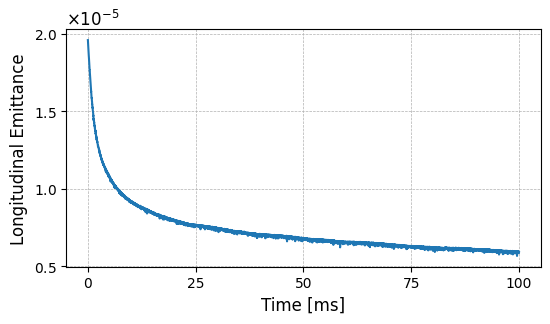

In [97]:
# Calculate figure size based on text width and golden ratio
fig_width = textwidth_in
fig_height = textwidth_in * aspect_ratio

plt.figure(figsize=(fig_width, fig_height))

# Plotting the data
plt.plot(time, longitudinal_emittance)

plt.xlabel('Time [ms]', fontsize=label_fontsize)
plt.ylabel('Longitudinal Emittance', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Adjust the format of the tick labels
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))
plt.gca().yaxis.set_major_formatter(formatter)
plt.gca().yaxis.get_offset_text().set_fontsize(offset_text_fontsize)  # Adjust the font size of the offset text

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
#plt.savefig('figures/longitudinal_emittance.png', dpi=300)  # Save with high resolution
plt.show()

look at longitudinal emittance in 2d plot instead of dp_p

1it [00:00,  2.16it/s]

56
82
laser offset -0.03355704697986534 mm


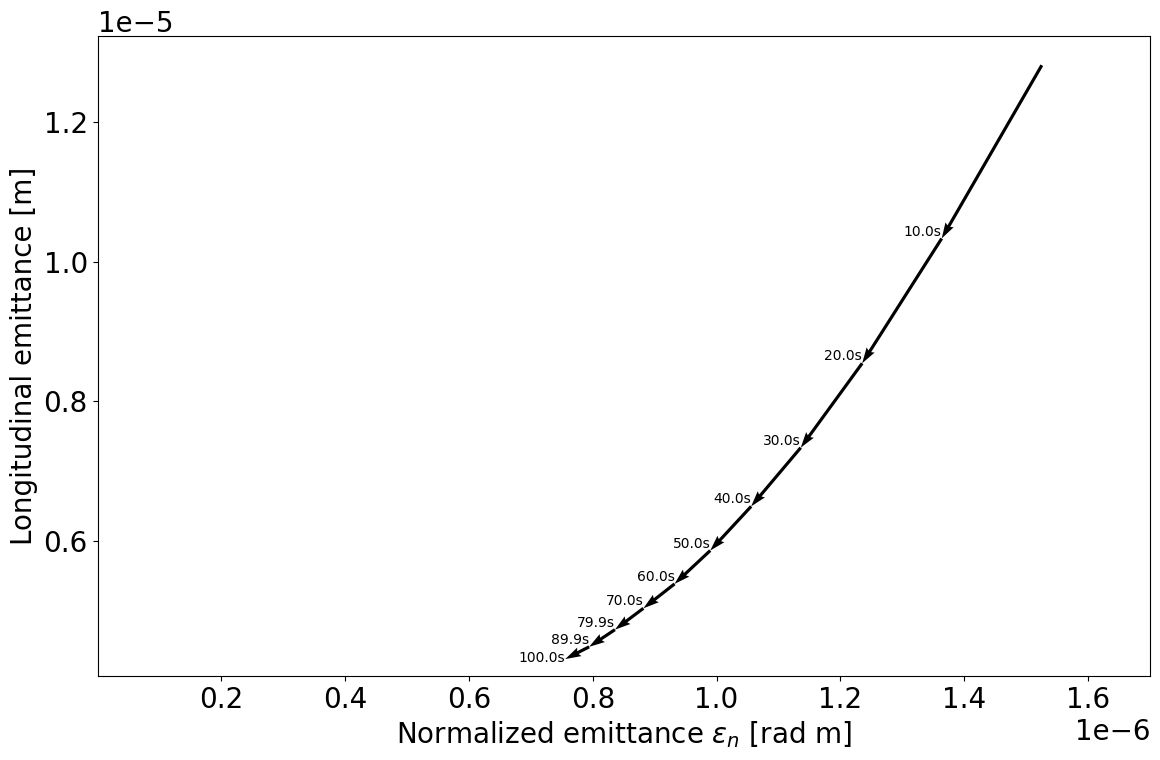

In [98]:
from tqdm import tqdm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
plt.rcParams.update({'font.size': 20})

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, ion_loop in tqdm(enumerate([lead])):    
    data = np.load(f'../results/IBS_bunched/{ion_loop.name}.npz')
    linear_results = np.load(f'results/{ion_loop.name}.npz')

    delta = linear_results['delta']
    zeta = linear_results['zeta']

    # Calculate mean and standard deviation along the particle axis (axis=1)
    mean_z = np.mean(zeta, axis=1)
    mean_delta = np.mean(delta, axis=1)
    sigma_z = np.std(zeta, axis=1)
    sigma_delta = np.std(delta, axis=1)

    # Calculate the covariance between zeta and delta for each turn
    cov_z_delta = np.mean(zeta * delta, axis=1) - mean_z * mean_delta

    # Calculate longitudinal emittance for each turn
    longitudinal_emittance = np.sqrt(sigma_z**2 * sigma_delta**2 - cov_z_delta**2)

    emittance_x = linear_results['emittance_x']
    time = linear_results['time']
    rms_dp_p = np.std(delta, axis=1)

    index_closest_to_40 = np.argmin(np.abs(time - 40))

    emittance_x_values = emittance_x[:]
    rms_dp_p_values = rms_dp_p[:]
    
    # Plot the contour
    growth_rates_2d_x = data['growth_rates_2d_x']
    growth_rates_2d_y = data['growth_rates_2d_y']
    growth_rates_2d_z = 0.5*data['growth_rates_2d_z']
    sig_delta_list = data['sig_delta_list']
    n_emitt_list = data['n_emitt_list']
    total_intensity = data['total_intensity']
    
    loaded_data = np.load(f'../results/optimal_laser_x/{ion_loop.name}.npz')
    transverse_growth_rate_list = loaded_data['transverse_growth_rate_list']
    longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_dp_p_list']
    #longitudinal_growth_rate_list=loaded_data['longitudinal_growth_rate_emittance_list']
    laser_x_list=loaded_data['laser_x_list']
   
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    min_longitudinal_index = np.argmin(longitudinal_growth_rate_list)
    print(min_transverse_index)
    print(min_longitudinal_index)

    #69  #74=0
    laser_position_index = 74
    laser_offset = laser_x_list[laser_position_index]
    print('laser offset',laser_offset*1e3,'mm')
    threshold_longitudinal2 = -longitudinal_growth_rate_list[laser_position_index]  # Set the threshold value
    threshold_transverse2 = -(transverse_growth_rate_list[laser_position_index])  # Set the threshold value

    
    threshold_transverse = -min(transverse_growth_rate_list)  # Set the threshold value
    min_transverse_index = np.argmin(transverse_growth_rate_list)
    threshold_longitudinal = -longitudinal_growth_rate_list[min_transverse_index]  # Set the threshold value
    

    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse, np.inf],
    #                 colors=cycle[0], linewidths=2)   

    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal],
    #                 colors=cycle[0], linestyles='--', linewidths=2)
    


    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_x, levels=[threshold_transverse2, np.inf],
    #                 colors=cycle[2], linewidths=2)   

    # plt.contour(n_emitt_list, sig_delta_list, growth_rates_2d_z, levels=[threshold_longitudinal2],
    #                 colors=cycle[2], linestyles='--', linewidths=2)


    # Define the number of segments for each arrow
    num_segments = 10
    
    # Calculate the step size for each segment
    step_size = len(time) // num_segments
    
    # Plot each segment as a quiver plot
    for j in range(num_segments):
        # Calculate the indices for the start and end points of the segment
        start_idx = j * step_size
        end_idx = min((j + 1) * step_size, len(time) - 1)
        
        # Calculate the start and end points of the segment
        start_x = emittance_x_values[start_idx]
        end_x = emittance_x_values[end_idx]
        
        start_y = longitudinal_emittance[start_idx]
        end_y = longitudinal_emittance[end_idx]
        
        # Plot the quiver plot for the segment
        arrow = plt.quiver(start_x, start_y, end_x - start_x, end_y - start_y, scale=1,
                            scale_units='xy', angles='xy', color='black', width=0.003)
        
        # Add time annotation at the end of the arrow
        time_annotation_x = end_x
        time_annotation_y = end_y
        if j == num_segments - 1:  # for the last arrow
            time_annotation_text = "100.0s"
            time_annotation_y=0.98*time_annotation_y
        else:
            time_annotation_text = f"{time[end_idx]:.1f}s"
        plt.text(time_annotation_x, time_annotation_y, time_annotation_text, color='black', fontsize=10, ha='right', va='bottom')
  

# Plotting the arrows on top completes, now let's adjust other settings        
injection_nemitt = emittance_x[0]
injection_dp_p = rms_dp_p[0]

# plt.scatter(injection_nemitt, injection_dp_p, color='red', label='Initial condition')
# plt.text(0.97*injection_nemitt, 0.98*injection_dp_p, 'Initial condition', color='red', fontsize=20, ha='right')        

plt.xlim([n_emitt_list[0], n_emitt_list[-1]])
plt.xlabel('Normalized emittance $\\epsilon_n$ [rad m]', fontsize=20)
plt.ylabel('Longitudinal emittance [m]', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# plt.legend(handles=[
#     Line2D([0], [0], linestyle='-', color=cycle[0],  label='Horizontal equilibrium '),
#     Line2D([0], [0], linestyle='--', color=cycle[0], label='Longitudinal equilibrium'),
          
# ], loc='lower right')


plt.tight_layout()
#plt.savefig('figures/Equilibrium_emittance.png', dpi=300)
plt.show()